In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
#from sklearn.metrics import RocCurveDisplay
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# DEFINE DATASET NAMES + FUNCTIONS

In [2]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365,np.inf][:],
                             'labels':[1,2]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 


                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
                         
                         }

# ROC-AUC ACROSS STUDIES

/tmp/ipykernel_244253/589591332.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/589591332.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/589591332.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/589591332.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/589591332.py:72: UserWarni

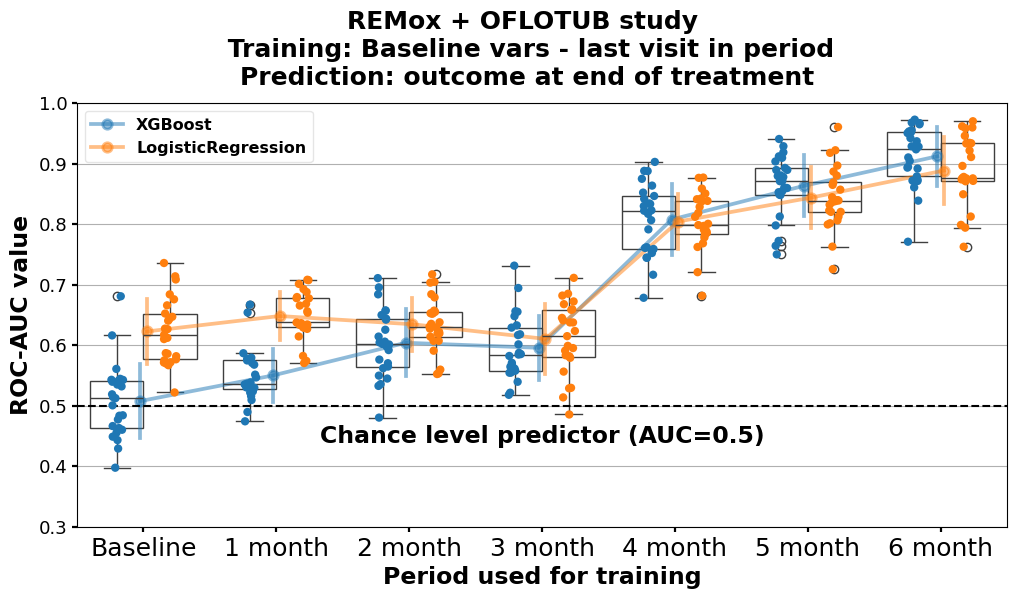

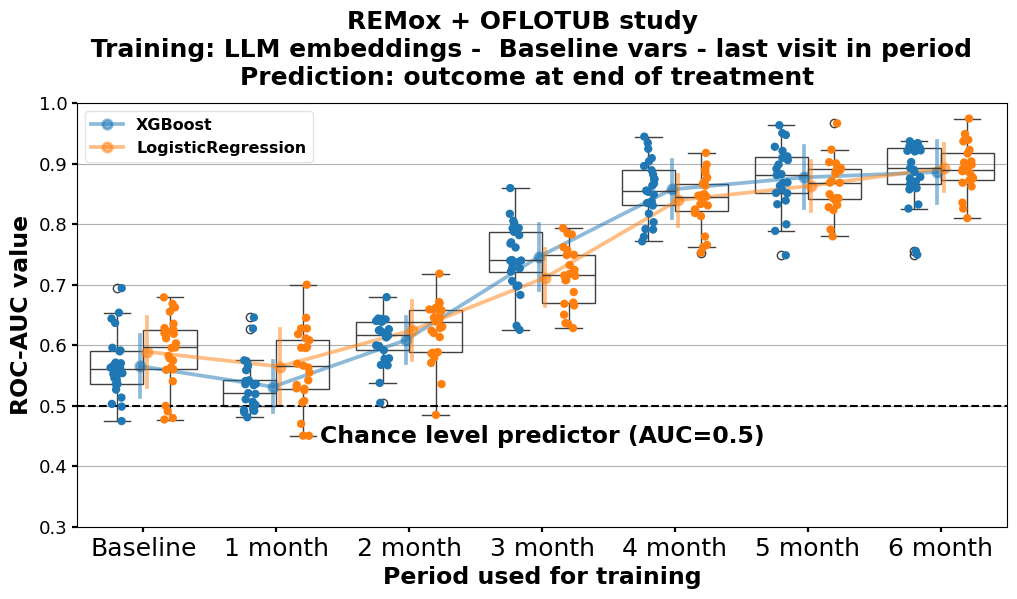

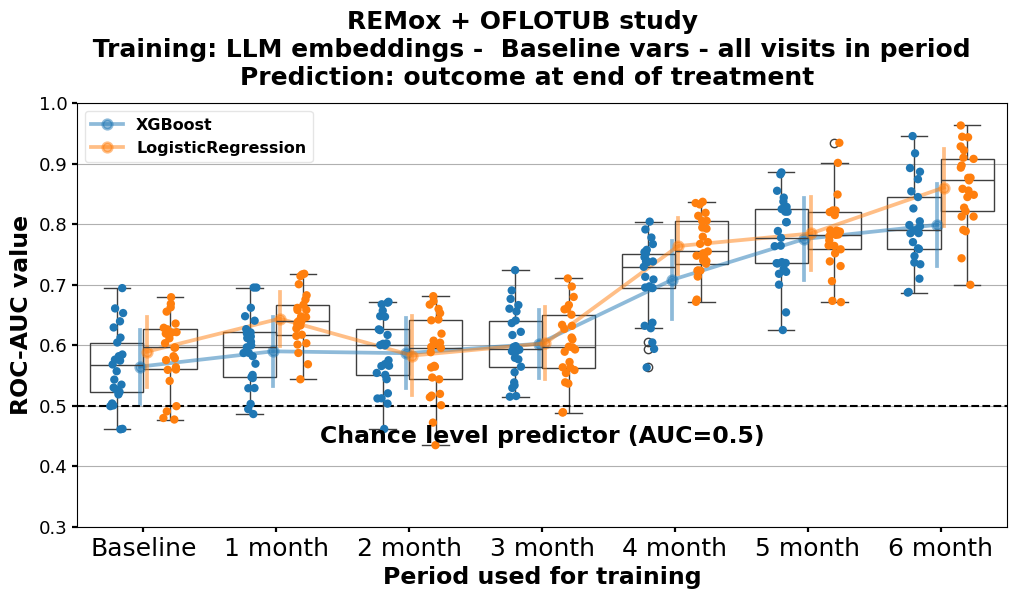

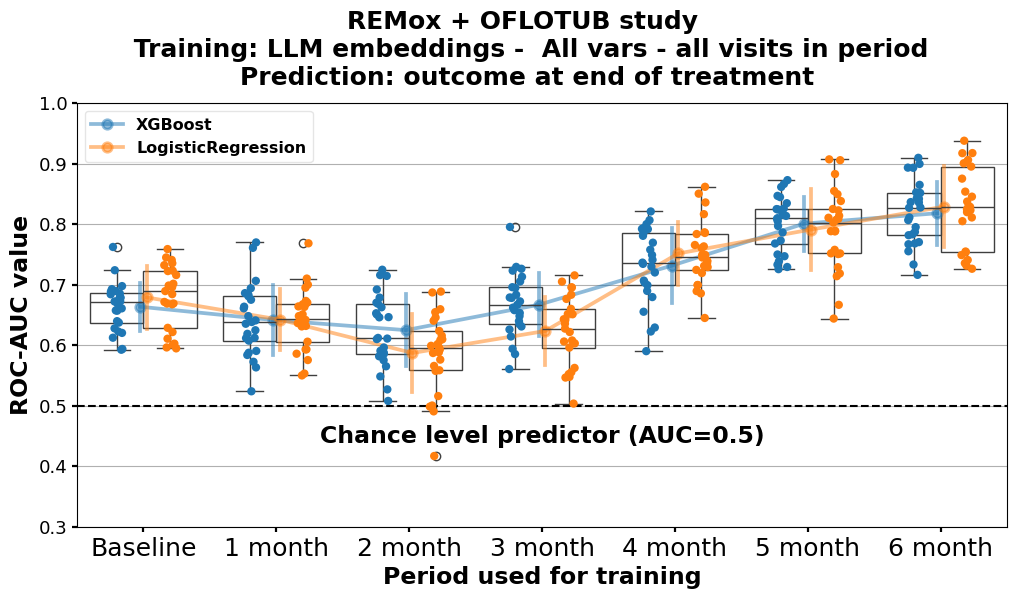

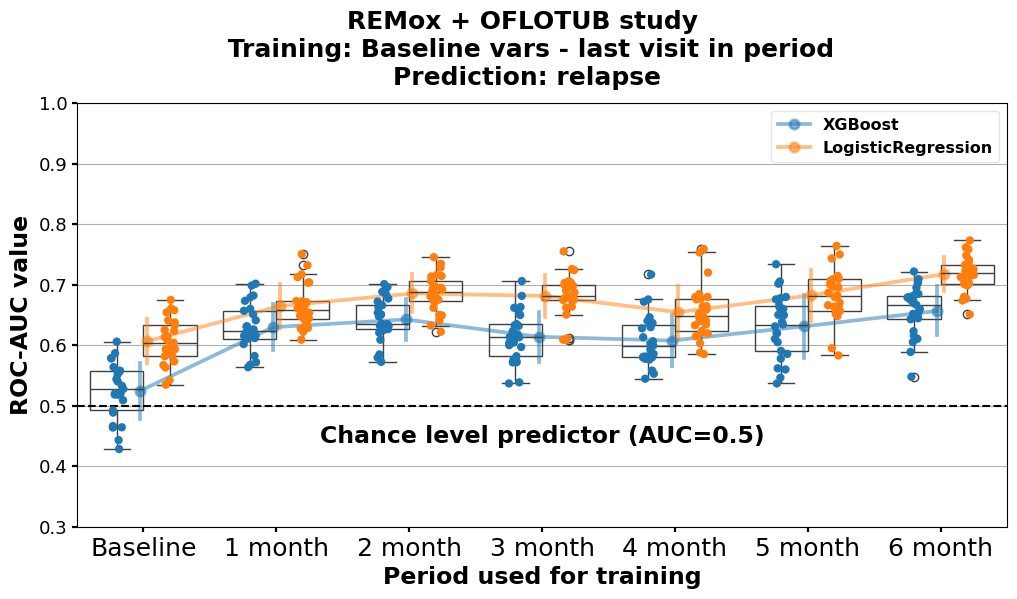

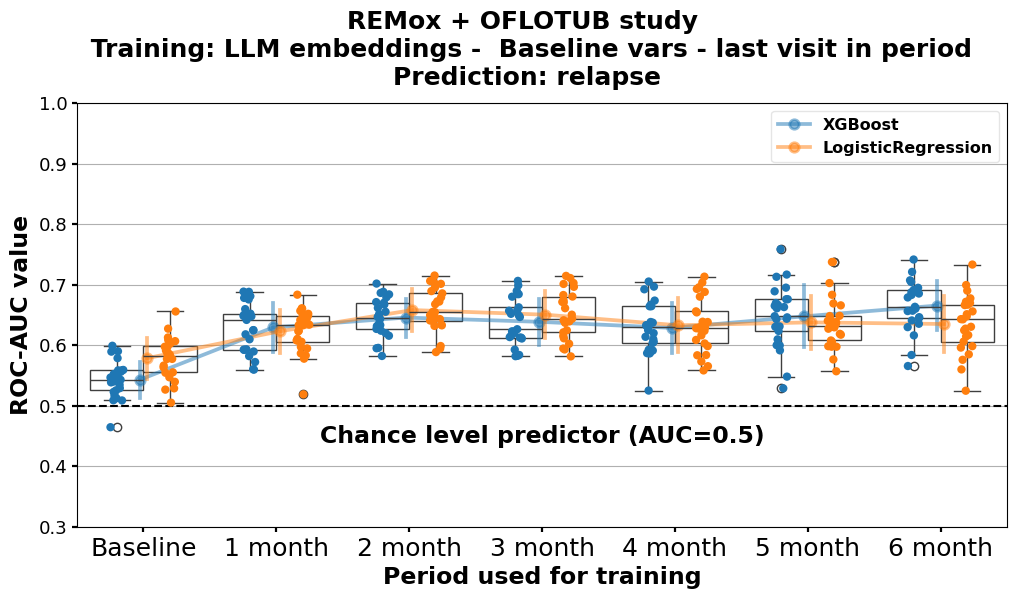

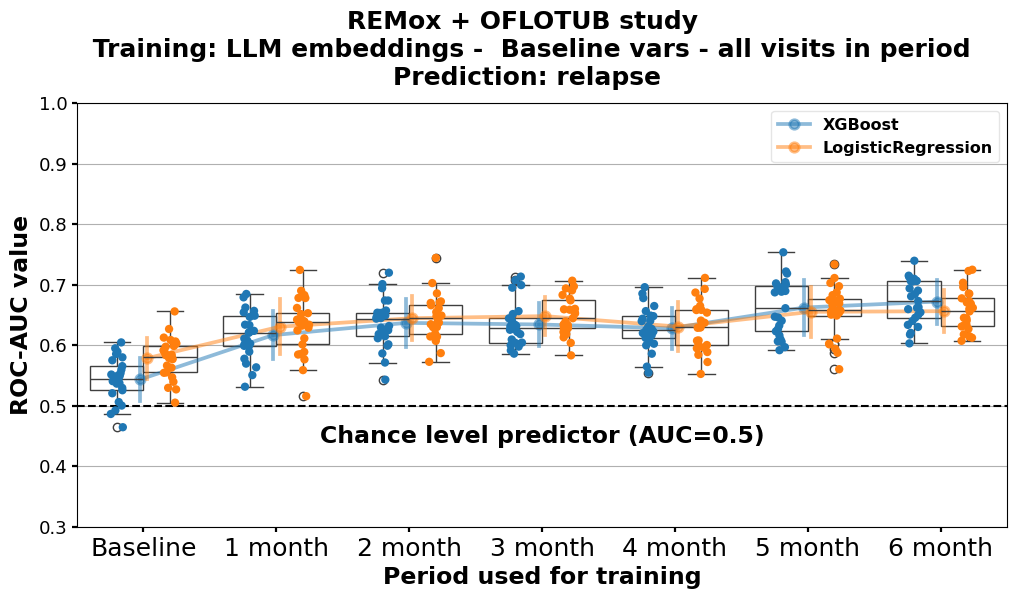

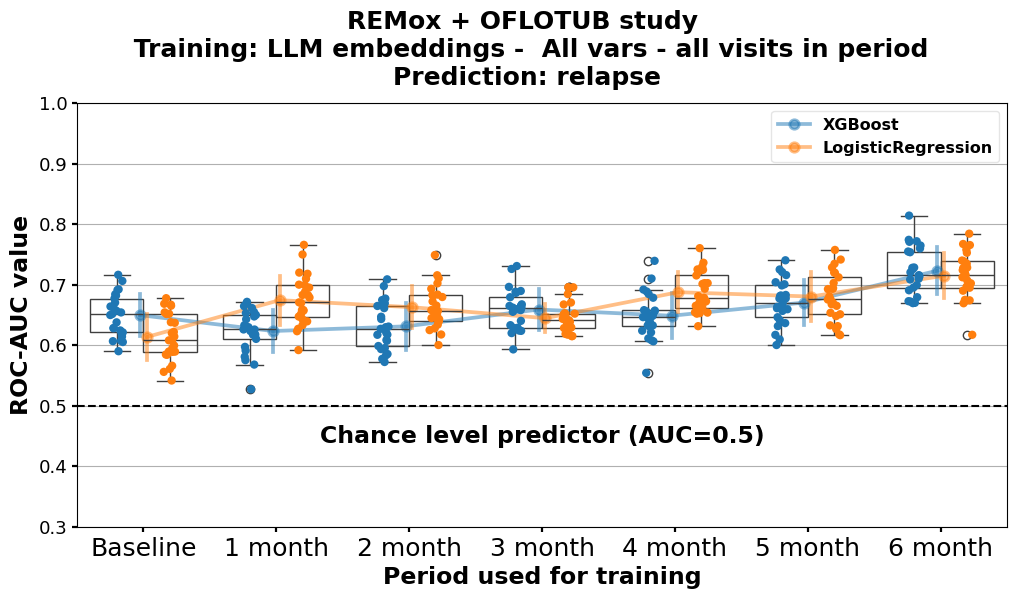

In [3]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][:2]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    #f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():
        #print(setup)

        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                        
        sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
        sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
        sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                      y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=True)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
    
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time = f'outcome at {prediction_time}'
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                train_ds_type=setup.replace('LLM','LLM embeddings - ')
                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        ax.yaxis.grid(True) 
    
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
        os.makedirs(data_dir_,exist_ok=True)
    
        exp_setup = train_ds_type.replace(' ','_').replace('-','__')
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        

# ROC-AUC PER STUDY

/tmp/ipykernel_244253/2434827739.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/2434827739.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/2434827739.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/2434827739.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
/tmp/ipykernel_244253/2434827739.py:69: User

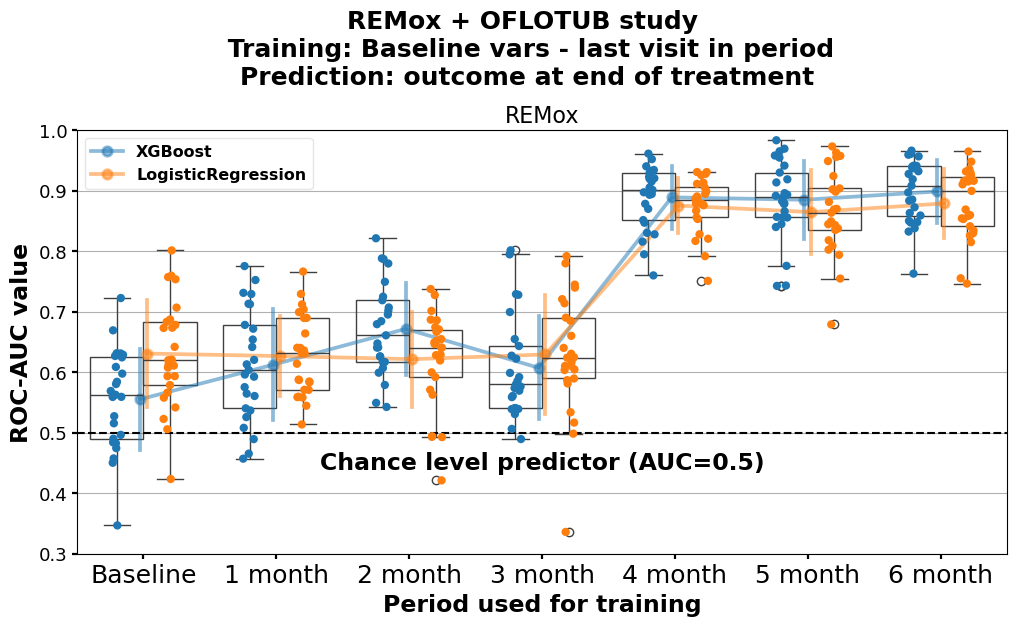

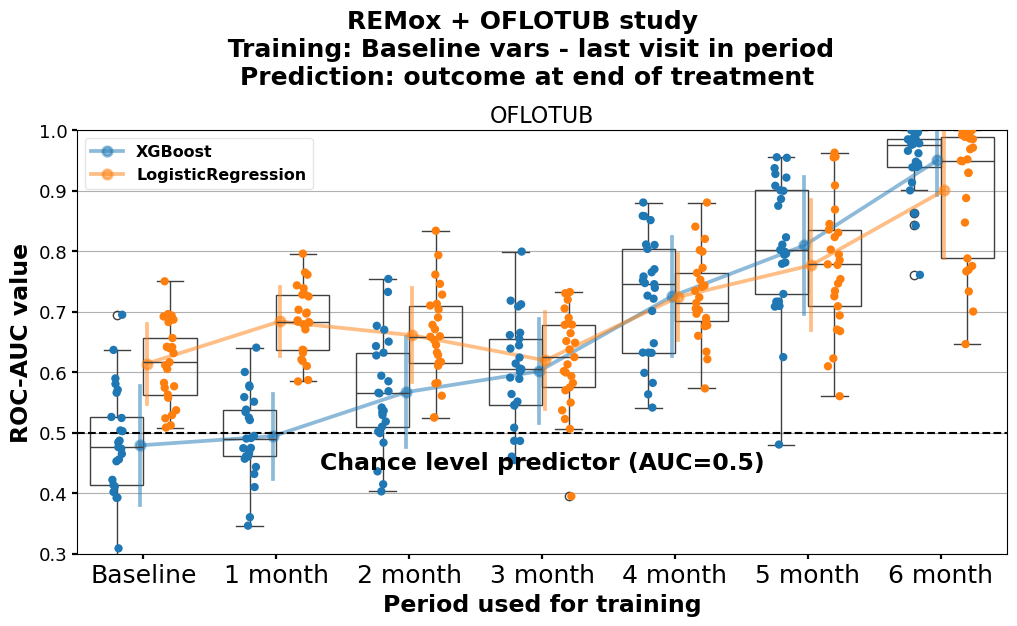

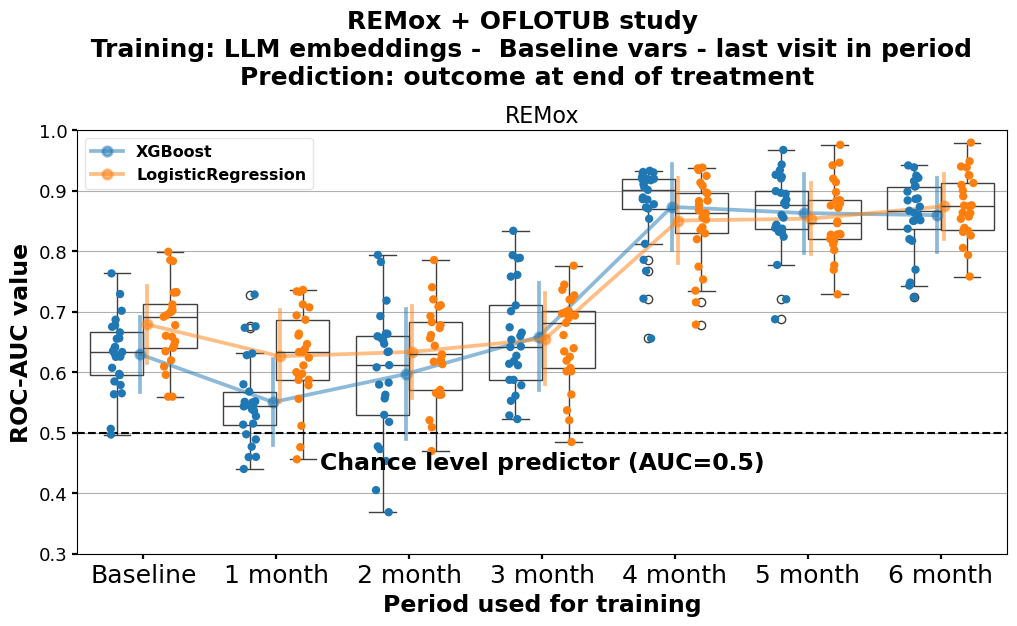

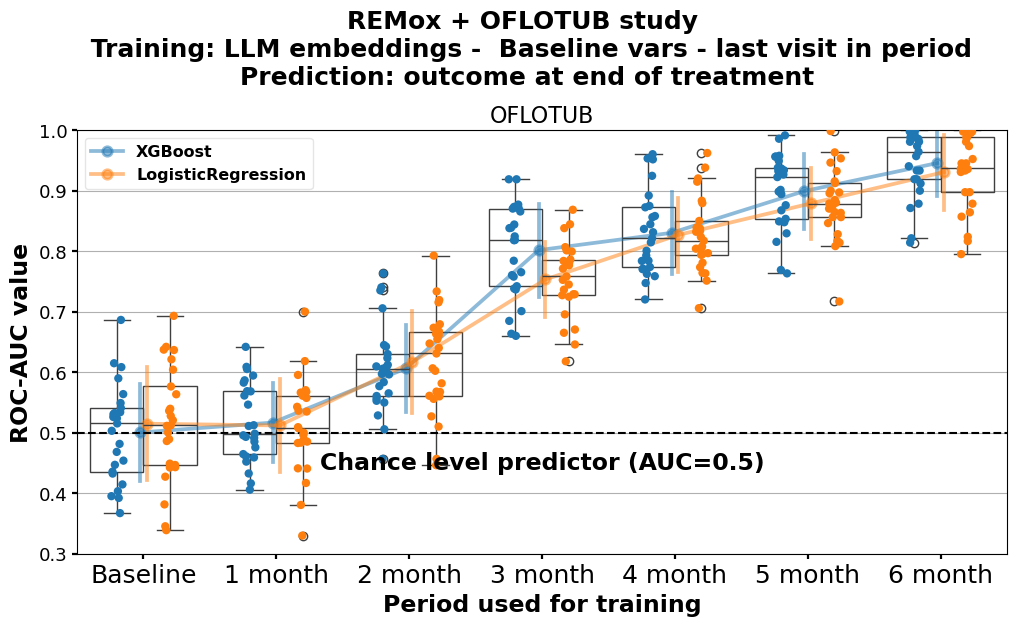

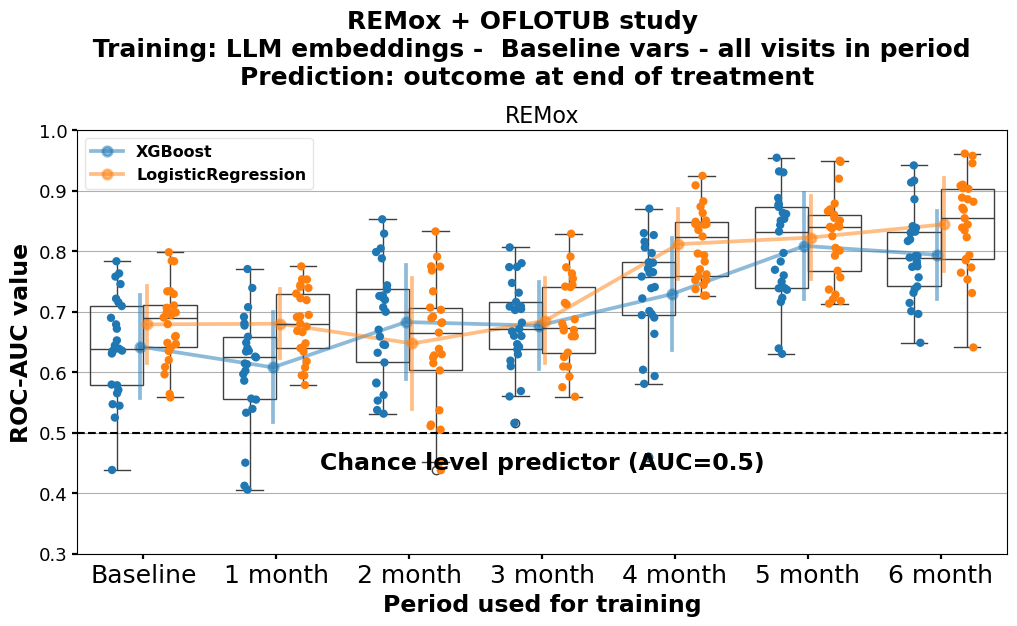

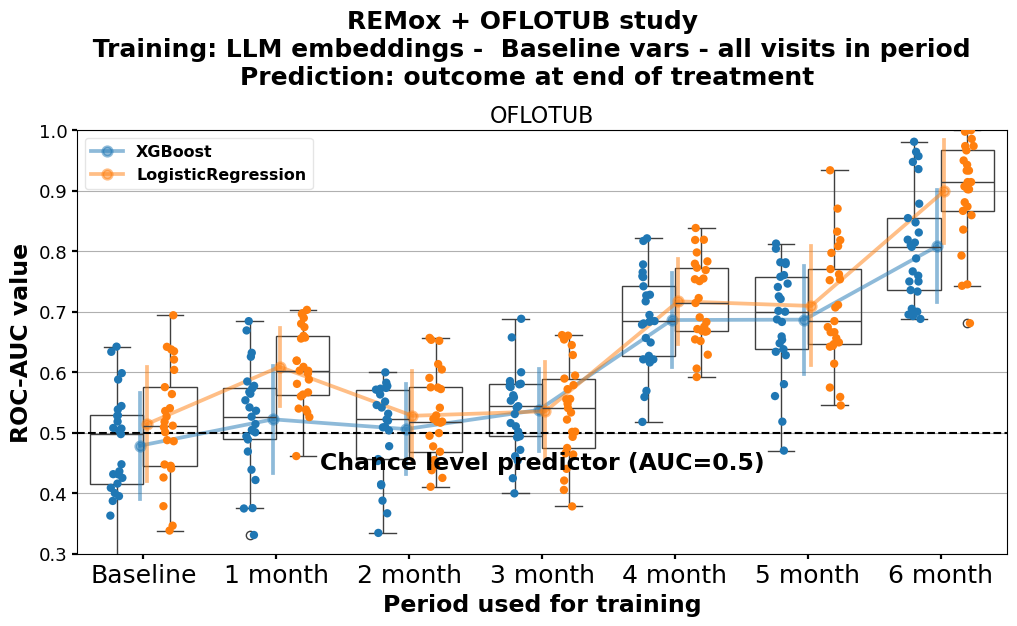

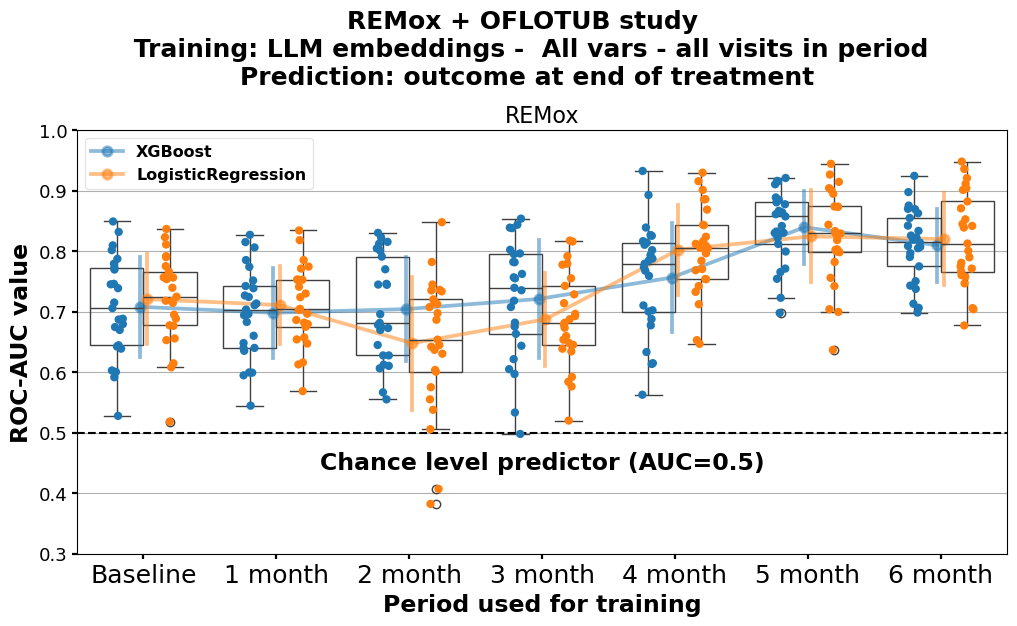

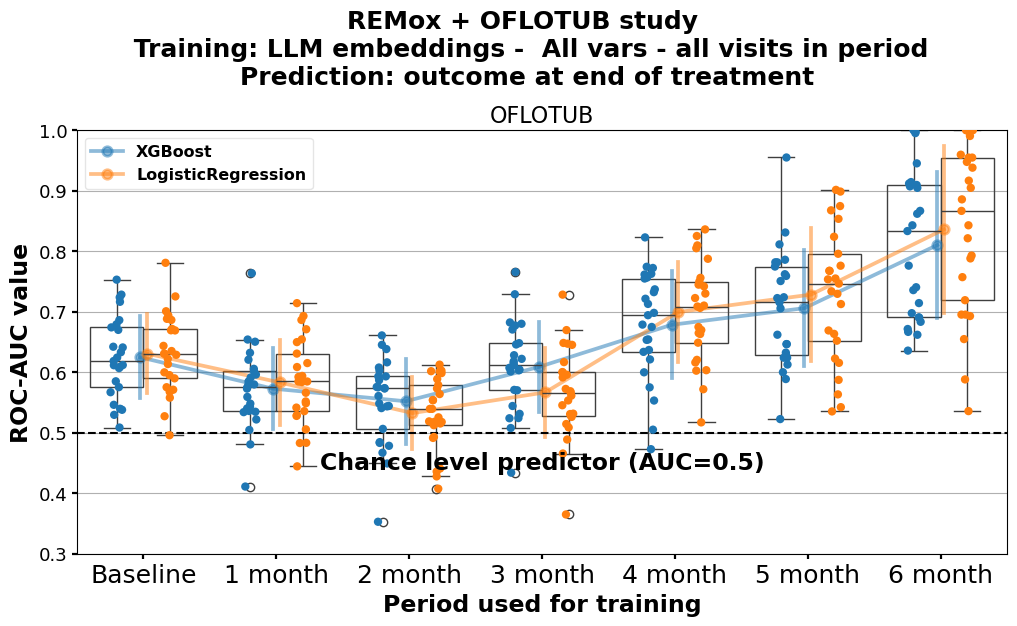

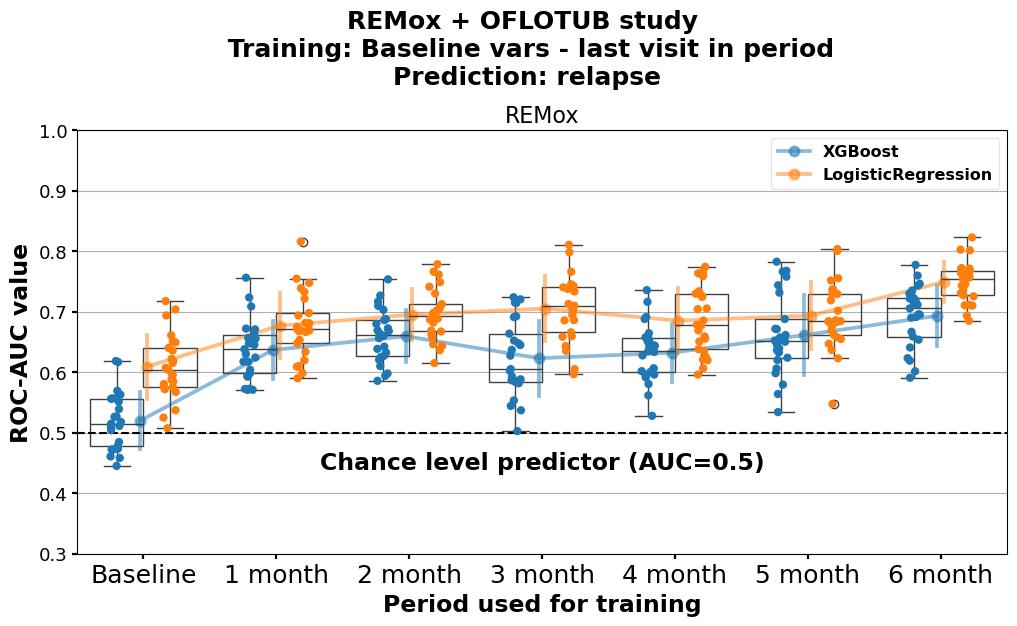

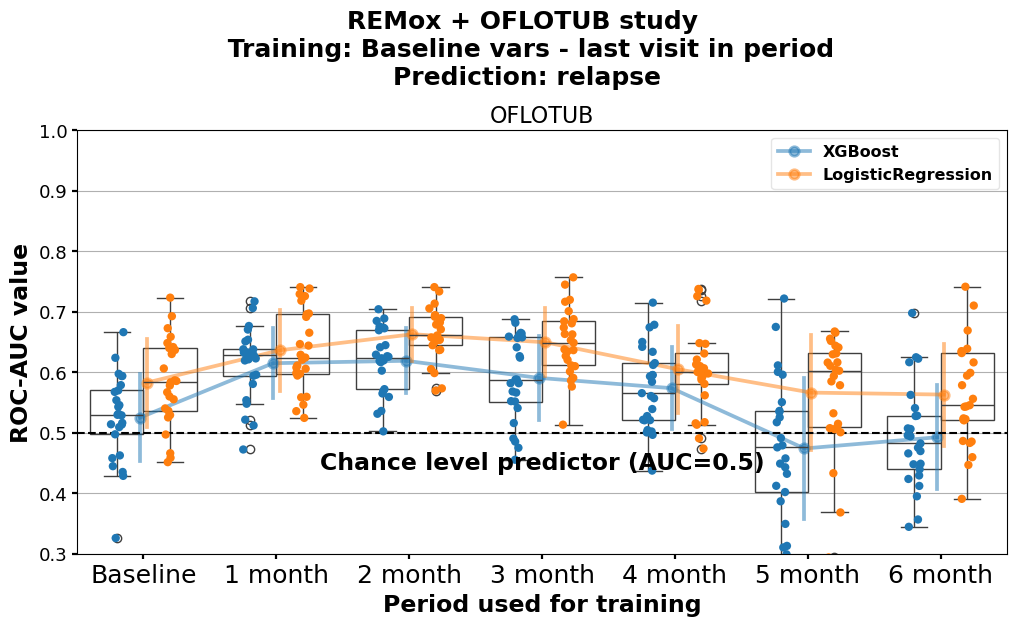

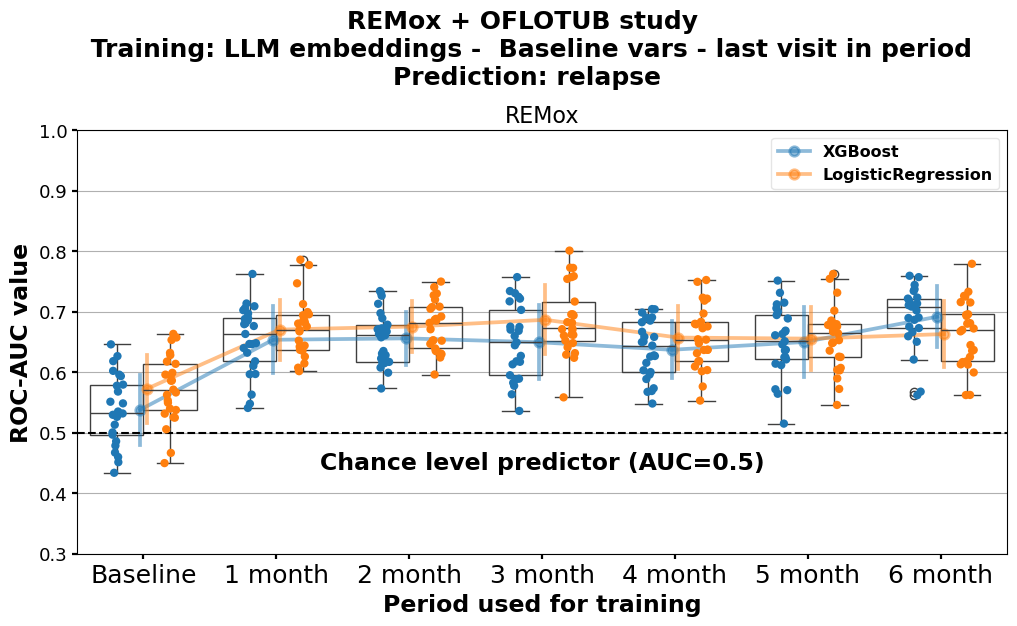

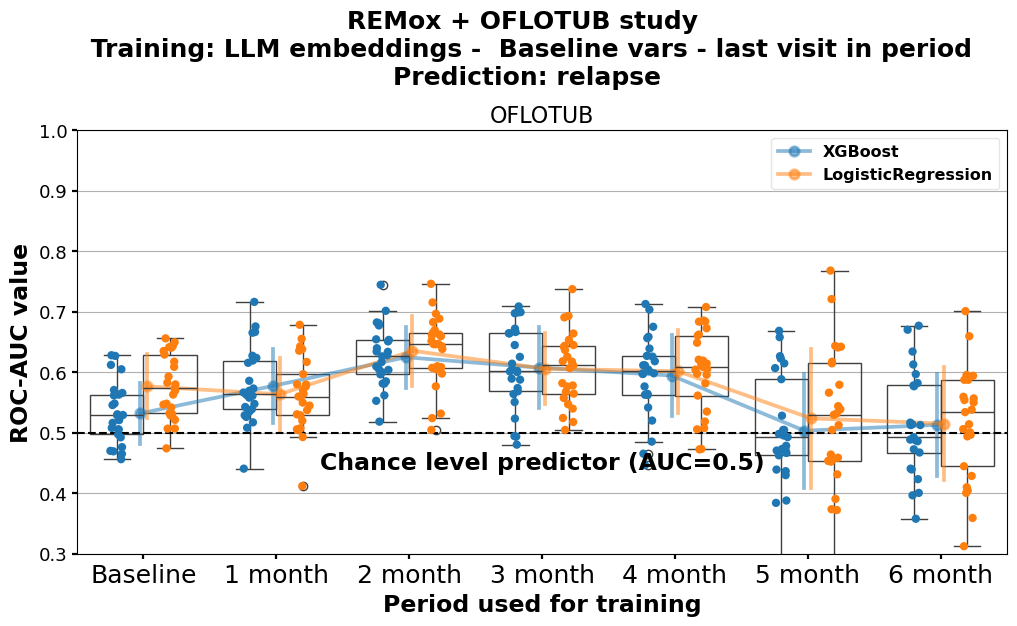

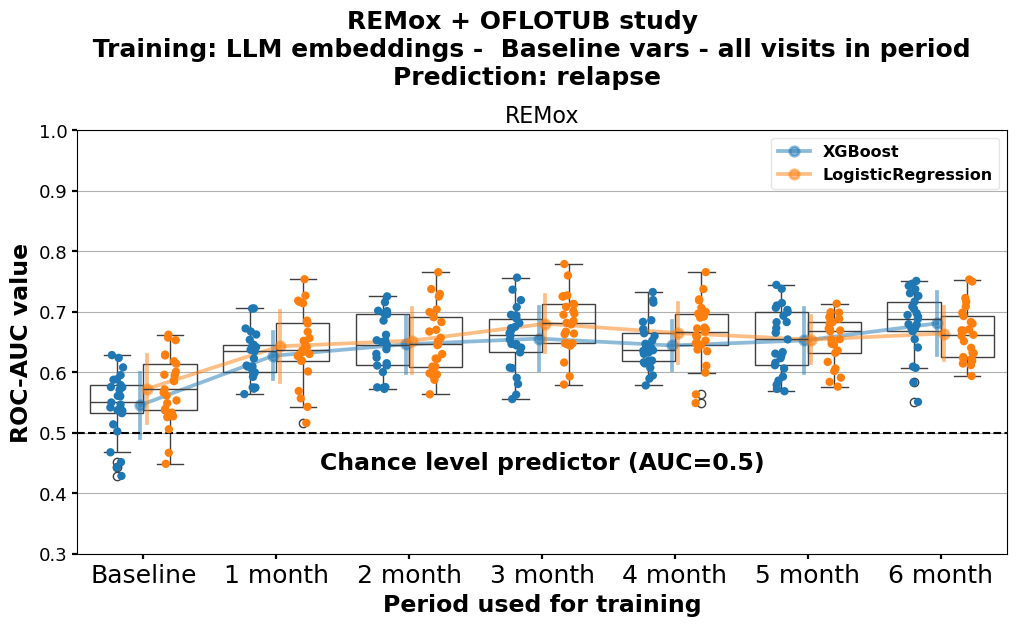

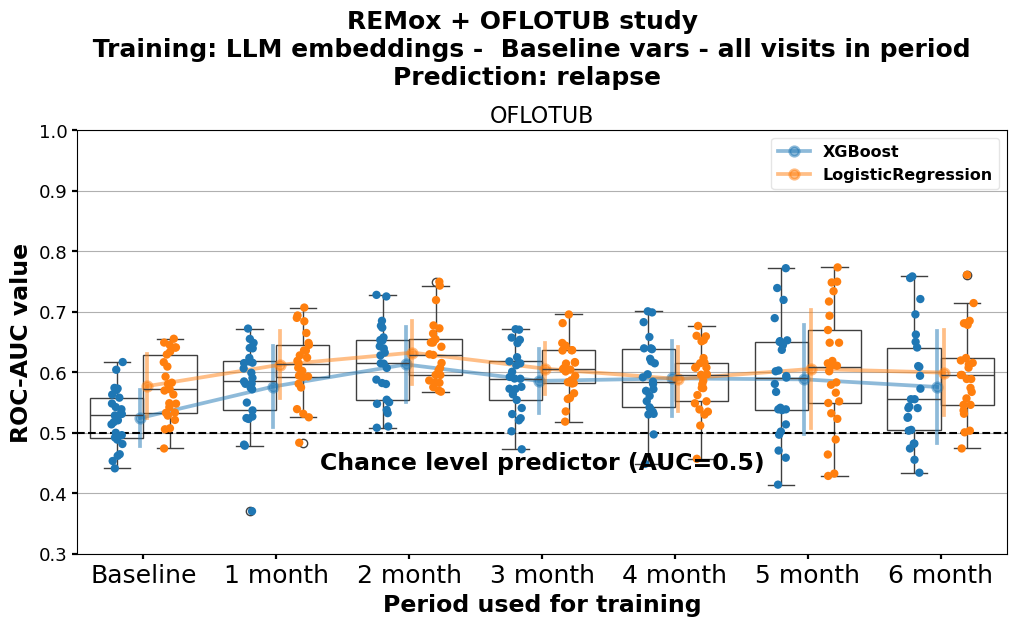

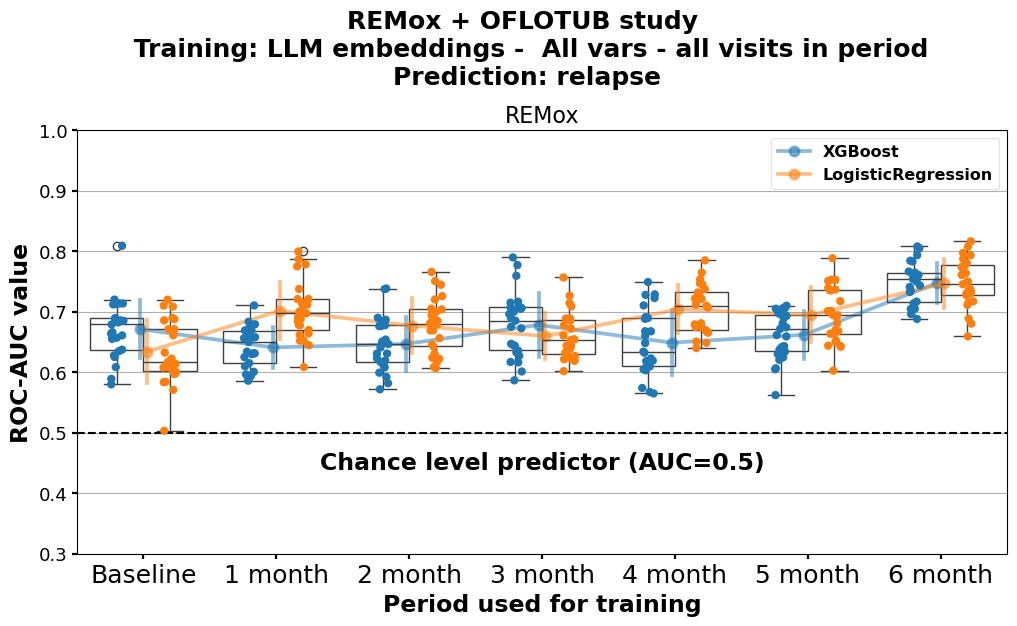

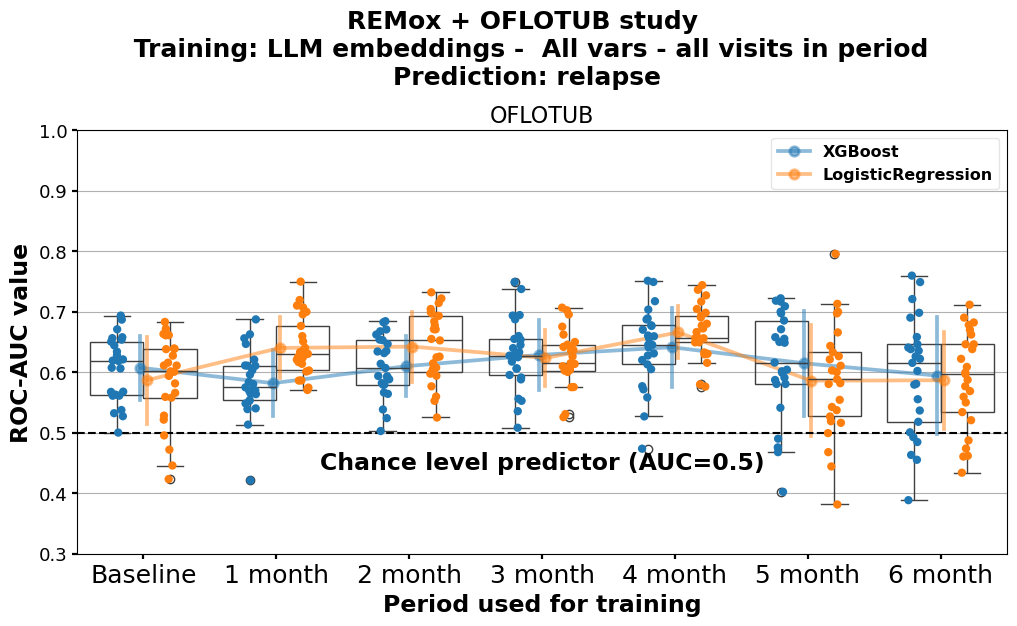

In [5]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]


    
for data_param_key in [*parameters_for_analysis][:2]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    #f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():

        for study in roc_auc_concat_df['STUDYID'].unique():
            

            fig,ax=plt.subplots(1,1,figsize=(12,5.5))
            
            plot_df=roc_auc_concat_df[(roc_auc_concat_df['setup']==setup)\
                                     &(roc_auc_concat_df['STUDYID']==study)]
                            
            sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                        y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
            sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                          y='ROC_AUC_score', ax=ax, #color='black',
                          size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
            sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                          y='ROC_AUC_score',ax=ax,
                          errorbar='sd',alpha=0.5,dodge=True)
        
            
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
            
            ## Convert days to months for xticklabels
            xticklabels=[ '6 month' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                            else None 
                            for day in period_end_days_for_plot]
        
            ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
            ax.set_ylim(0.3,1) 
        
            # Adjust legend: changing font size and handle size
            h, l = ax.get_legend_handles_labels()
            legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
            
            ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})
        
        
        
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)
        
            
        
            if data_param_key in suptitle_dict.keys():
                    study_names=suptitle_dict[data_param_key]
                
                    if 'relapse' not in data_param_key:
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        prediction_time = f'outcome at {prediction_time}'
                    if 'relapse' in data_param_key:
                        prediction_time='relapse'
                    #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                    train_ds_type=setup.replace('LLM','LLM embeddings - ')
                    suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                    
            else:   
                suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
        
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.1)  
            
            ax.set_title(f"{suptitle_dict[study]}",fontsize=subtitle_size)
            ax.yaxis.grid(True) 
        
        
            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
            os.makedirs(data_dir_,exist_ok=True)
        
            exp_setup = train_ds_type.replace(' ','_').replace('-','__')
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
            #print(f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()
    
        